모델 학습

In [1]:
import os
import sys
import sqlite3
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import gc
from pathlib import Path
from IPython.display import display
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score

In [2]:
# 1. 환경 설정 및 드라이브 마운트
IN_COLAB = 'COLAB_RELEASE_TAG' in os.environ
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
MANUAL_PROJECT_ROOT = ''
PROJECT_ROOT_CANDIDATES = [
    '/content/drive/MyDrive/Graduate-Project/Falling-Detection-Development',
    '/content/drive/MyDrive/졸업 과제/Falling-Detection-Development',
    '/content/Falling-Detection-Development',
    str(Path.cwd()),
]

candidate_paths = [MANUAL_PROJECT_ROOT] + PROJECT_ROOT_CANDIDATES if MANUAL_PROJECT_ROOT else PROJECT_ROOT_CANDIDATES
PROJECT_ROOT = None
for candidate in candidate_paths:
    path = Path(candidate)
    if (path / 'scripts').exists() and (path / 'dataset').exists():
        PROJECT_ROOT = path.resolve()
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError('프로젝트 루트를 찾지 못했습니다. train_gru_v26.py 파일 위치를 확인하세요.')

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_ROOT = PROJECT_ROOT / 'dataset'
ARTIFACT_ROOT = PROJECT_ROOT / 'artifacts' / 'gru_v26_final_notebook'

print('PROJECT_ROOT =', PROJECT_ROOT)
print('DATA_ROOT =', DATA_ROOT)
print('ARTIFACT_ROOT =', ARTIFACT_ROOT)

PROJECT_ROOT = /content/drive/.shortcut-targets-by-id/1sPM3m7rEt6UUnWt9ulH3rzFYhguMJMUY/졸업 과제/Falling-Detection-Development
DATA_ROOT = /content/drive/.shortcut-targets-by-id/1sPM3m7rEt6UUnWt9ulH3rzFYhguMJMUY/졸업 과제/Falling-Detection-Development/dataset
ARTIFACT_ROOT = /content/drive/.shortcut-targets-by-id/1sPM3m7rEt6UUnWt9ulH3rzFYhguMJMUY/졸업 과제/Falling-Detection-Development/artifacts/gru_v26_final_notebook


In [ ]:
# 2. 유틸리티 임포트 (scripts.train_tcn_v2 / train_tcn_v25 사용)
from scripts.train_tcn_v2 import (
    load_source_frame, log, set_seed, normalize_splits,
    make_tf_dataset, compile_model, build_split_metrics,
    save_run_metadata, save_visualization_artifacts,
    train_model,
)
from scripts.train_tcn_v25 import (
    build_monitoring_segments, build_sliding_window_dataset,
    describe_window_split, split_segments,
)

# ── GruV26TrainConfig / refine_labels 인라인 정의 ─────────────────────────────
from dataclasses import dataclass
from typing import Optional

@dataclass
class GruV26TrainConfig:
    input_format: str
    csv_path: str
    sqlite_path: str
    sqlite_table: str
    output_dir: str
    monitor_start_sec: float
    monitor_end_sec: float
    target_steps: int
    label_mode: str
    batch_size: int
    epochs: int
    learning_rate: float
    random_state: int
    dropout_rate: float
    hidden_sizes: list
    export_tflite: bool
    train_positive_stride: int
    train_negative_stride: int
    eval_stride: int
    decision_threshold: Optional[float] = None
    min_val_recall: float = 0.85
    positive_weight: float = 1.5
    soft_label_value: float = 0.9

def refine_labels(model, x, y):
    """high-confidence 예측으로만 라벨 교체 (0.95 / 0.05 경계)."""
    probs = model.predict(x, batch_size=256, verbose=1)[:, 1]
    new_labels = y.copy()
    new_labels[probs > 0.95] = 1
    new_labels[probs < 0.05] = 0
    pos = int(np.sum((y == 0) & (new_labels == 1)))
    neg = int(np.sum((y == 1) & (new_labels == 0)))
    print(f"Refinement: {pos} normal→fall, {neg} fall→normal")
    if pos > len(y) * 0.2:
        print("WARNING: 라벨 20% 이상 Positive 전환 — 노이즈 오버피팅 주의")
    return new_labels


In [5]:
def build_gru_v2_model(config, input_shape):
    inputs = tf.keras.Input(shape=input_shape, name="pose_sequence")
    x = inputs

    for layer_idx, hidden_size in enumerate(config.hidden_sizes, start=1):
        return_sequences = layer_idx < len(config.hidden_sizes)
        x = tf.keras.layers.GRU(
            hidden_size,
            return_sequences=return_sequences,
            dropout=config.dropout_rate,
            recurrent_dropout=0.0,
            reset_after=True,
            unroll=True,
            activation='tanh',
            recurrent_activation='sigmoid',
            name=f"gru_{layer_idx}",
        )(x)

    x = tf.keras.layers.Dense(config.hidden_sizes[-1], activation="relu", name="head_dense")(x)
    x = tf.keras.layers.Dropout(config.dropout_rate, name="head_drop")(x)
    outputs = tf.keras.layers.Dense(2, activation="softmax", name="classifier")(x)
    return tf.keras.Model(inputs=inputs, outputs=outputs, name="stm32_gru_v2_classifier")

In [6]:
# 3. 설정 및 데이터 준비
config = GruV26TrainConfig(
    input_format='csv',
    csv_path=str(DATA_ROOT / 'final_dataset.csv'),
    sqlite_path=str(DATA_ROOT / 'final_dataset.sqlite'),
    sqlite_table='fall_frames',
    output_dir=str(ARTIFACT_ROOT),
    monitor_start_sec=0.0,
    monitor_end_sec=10.0,
    target_steps=60,
    label_mode='segment_max',
    batch_size=64,
    epochs=50,
    learning_rate=3e-4,
    random_state=42,
    dropout_rate=0.3,
    hidden_sizes=[64, 32],
    export_tflite=True,
    train_positive_stride=3,
    train_negative_stride=10,
    eval_stride=1,
    decision_threshold=0.8,
    min_val_recall=0.85,
    positive_weight=1.5,
    soft_label_value=0.9
)

set_seed(config.random_state)
df, feature_cols = load_source_frame(config)
segments = build_monitoring_segments(df, feature_cols, config.monitor_start_sec, config.monitor_end_sec)

del df
gc.collect()

[2026-05-07 15:49:59] loading csv source from /content/drive/.shortcut-targets-by-id/1sPM3m7rEt6UUnWt9ulH3rzFYhguMJMUY/졸업 과제/Falling-Detection-Development/dataset/final_dataset.csv
[2026-05-07 15:51:10] csv rows loaded=4093620 feature_count=55


0

In [7]:
split_maps = split_segments(segments, config.random_state)


x_train, y_train, group_train = build_sliding_window_dataset(
    split_maps["train"],
    config.target_steps,
    config.label_mode,
    training=True,
    positive_stride=config.train_positive_stride,
    negative_stride=config.train_negative_stride,
    eval_stride=config.eval_stride
)

In [8]:
x_val, y_val, group_val = build_sliding_window_dataset(
    split_maps["val"],
    config.target_steps,
    config.label_mode,
    training=False,
    positive_stride=config.train_positive_stride,
    negative_stride=config.train_negative_stride,
    eval_stride=config.eval_stride
)

x_test, y_test, group_test = build_sliding_window_dataset(
    split_maps["test"],
    config.target_steps,
    config.label_mode,
    training=False,
    positive_stride=config.train_positive_stride,
    negative_stride=config.train_negative_stride,
    eval_stride=config.eval_stride
)

del segments, split_maps
gc.collect()

0

In [9]:
# 데이터 정규화
mean = np.mean(x_train, axis=(0, 1))
std = np.std(x_train, axis=(0, 1)) + 1e-7

x_train -= mean
x_train /= std

x_val -= mean
x_val /= std

x_test -= mean
x_test /= std

gc.collect()

0

In [ ]:
# 데이터 정규화 (시스템 RAM 부족)
#x_train, x_val, x_test, mean, std = normalize_splits(x_train, x_val, x_test)

#gc.collect()

In [10]:
print(f"최종 학습 데이터 크기: {x_train.nbytes / 1e9:.2f} GB")

최종 학습 데이터 크기: 5.38 GB


In [11]:
# 4. 시각화 및 평가 함수
def plot_history(history):
    history_df = pd.DataFrame(history.history)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    history_df[['loss', 'val_loss']].plot(ax=axes[0], marker='o')
    axes[0].set_title('Training & Validation Loss')
    axes[1].set_title('Metric Curves')
    history_df[[col for col in ['accuracy', 'val_accuracy', 'recall', 'val_recall'] if col in history_df.columns]].plot(ax=axes[1], marker='o')
    plt.show()

def plot_confusion(cm, split_name):
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{split_name} Confusion Matrix')
    plt.show()

In [12]:
# 대체용 dataset 생성 코드
# 기존 train_tcn_v2의 make_tf_dataset 코드 대체 (시스템 RAM 부족)
def make_tf_dataset(x, y, batch_size, training=True):
    with tf.device('/cpu:0'):
        dataset = tf.data.Dataset.from_tensor_slices((x, y))

        if training:
            dataset = dataset.shuffle(buffer_size=min(len(x), 50000))

        dataset = dataset.batch(batch_size)
        dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

In [13]:
# 5. v26 2단계 학습 파이프라인 실행
model = build_gru_v2_model(config, input_shape=(config.target_steps, len(feature_cols)))
model = compile_model(model, config.learning_rate)


class_weight = {0: 1.0, 1: config.positive_weight}

print("\n[STEP 1] Initial Training...")
train_model(model, make_tf_dataset(x_train, y_train, 64, True),
                  make_tf_dataset(x_val, y_val, 64, False), 15, class_weight)

gc.collect()


[STEP 1] Initial Training...
Epoch 1/15
6366/6366 ━━━━━━━━━━━━━━━━━━━━ 215s 20ms/step - accuracy: 0.8085 - loss: 0.4809 - pr_auc: 0.9333 - precision: 0.8043 - recall: 0.9504 - val_accuracy: 0.7331 - val_loss: 0.5294 - val_pr_auc: 0.9045 - val_precision: 0.6154 - val_recall: 0.9559 - learning_rate: 3.0000e-04
Epoch 2/15
6366/6366 ━━━━━━━━━━━━━━━━━━━━ 46s 7ms/step - accuracy: 0.8445 - loss: 0.3933 - pr_auc: 0.9606 - precision: 0.8450 - recall: 0.9454 - val_accuracy: 0.7683 - val_loss: 0.4825 - val_pr_auc: 0.9184 - val_precision: 0.6514 - val_recall: 0.9533 - learning_rate: 3.0000e-04
Epoch 3/15
6366/6366 ━━━━━━━━━━━━━━━━━━━━ 46s 7ms/step - accuracy: 0.8536 - loss: 0.3713 - pr_auc: 0.9658 - precision: 0.8536 - recall: 0.9478 - val_accuracy: 0.7765 - val_loss: 0.4690 - val_pr_auc: 0.9229 - val_precision: 0.6602 - val_recall: 0.9537 - learning_rate: 3.0000e-04
Epoch 4/15
6366/6366 ━━━━━━━━━━━━━━━━━━━━ 46s 7ms/step - accuracy: 0.8581 - loss: 0.3604 - pr_auc: 0.9680 - precision: 0.8576 - rec

120

In [14]:
# 기존 train_gru_v26의 refine_labels 코드 대체 (라벨링 추가 개선)

def refine_labels_safe(model, x_train, y_train):
    probs = model.predict(x_train, batch_size=256, verbose=1)[:, 1]

    new_labels = y_train.copy()

    # high-confidence만 반영
    high_conf_pos = probs > 0.95
    high_conf_neg = probs < 0.05

    new_labels[high_conf_pos] = 1
    new_labels[high_conf_neg] = 0

    print("Refinement stats:")
    print("  pos added:", np.sum((y_train == 0) & (new_labels == 1)))
    print("  neg added:", np.sum((y_train == 1) & (new_labels == 0)))

    # 로그 코드
    changed_to_pos = np.sum((y_train == 0) & (new_labels == 1))
    changed_to_neg = np.sum((y_train == 1) & (new_labels == 0))
    log(f"Self-Labeling Summary: {changed_to_pos} Normal -> Fall, {changed_to_neg} Fall -> Normal")

    if changed_to_pos > len(y_train) * 0.2:
        log("⚠️ WARNING: Too many labels changed to Positive. Model might be overfitting to noise.")

    return new_labels

In [15]:
print("\n[STEP 2] Self-Labeling Process...")
y_train_refined = refine_labels_safe(model, x_train, y_train)
gc.collect()


[STEP 2] Self-Labeling Process...
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 37s 13ms/step
Refinement stats:
  pos added: 2674
  neg added: 91
[2026-05-07 16:08:17] Self-Labeling Summary: 2674 Normal -> Fall, 91 Fall -> Normal


331

In [16]:
print("\n[STEP 3] Final Fine-tuning...")
history = train_model(
    model,
    make_tf_dataset(x_train, y_train_refined, config.batch_size, True),
    make_tf_dataset(x_val, y_val, config.batch_size, False),
    config.epochs,
    class_weight
)

gc.collect()


[STEP 3] Final Fine-tuning...
Epoch 1/50
6366/6366 ━━━━━━━━━━━━━━━━━━━━ 49s 8ms/step - accuracy: 0.8803 - loss: 0.2959 - pr_auc: 0.9803 - precision: 0.8806 - recall: 0.9556 - val_accuracy: 0.8071 - val_loss: 0.4223 - val_pr_auc: 0.9312 - val_precision: 0.6957 - val_recall: 0.9534 - learning_rate: 3.0000e-04
Epoch 2/50
6366/6366 ━━━━━━━━━━━━━━━━━━━━ 48s 7ms/step - accuracy: 0.8802 - loss: 0.2958 - pr_auc: 0.9804 - precision: 0.8809 - recall: 0.9552 - val_accuracy: 0.8033 - val_loss: 0.4311 - val_pr_auc: 0.9298 - val_precision: 0.6908 - val_recall: 0.9544 - learning_rate: 3.0000e-04
Epoch 3/50
6366/6366 ━━━━━━━━━━━━━━━━━━━━ 47s 7ms/step - accuracy: 0.8810 - loss: 0.2940 - pr_auc: 0.9807 - precision: 0.8818 - recall: 0.9552 - val_accuracy: 0.8223 - val_loss: 0.4014 - val_pr_auc: 0.9313 - val_precision: 0.7171 - val_recall: 0.9460 - learning_rate: 3.0000e-04
Epoch 4/50
6366/6366 ━━━━━━━━━━━━━━━━━━━━ 47s 7ms/step - accuracy: 0.8810 - loss: 0.2929 - pr_auc: 0.9808 - precision: 0.8821 - reca

118

[2026-05-07 16:16:16] using fixed decision threshold threshold=0.8000


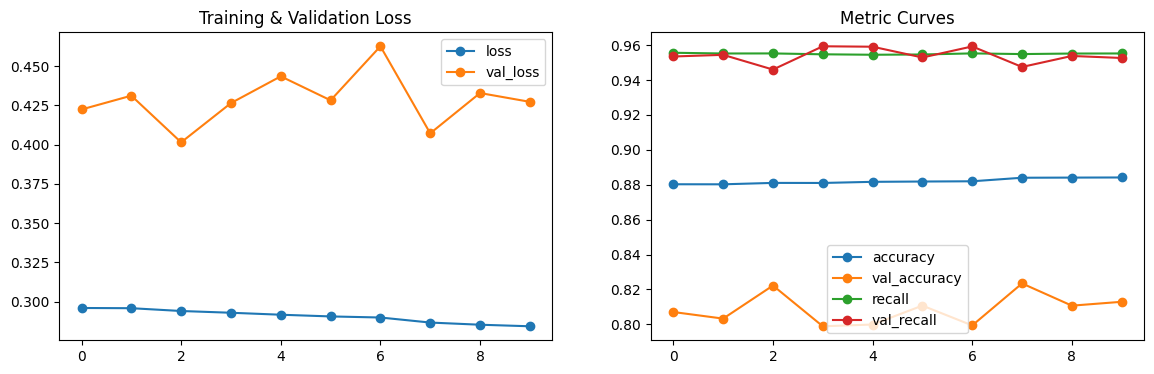

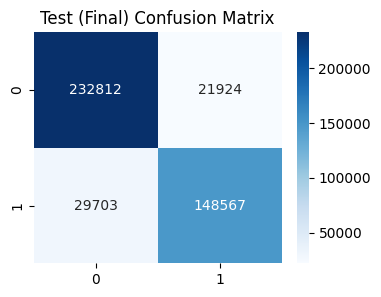

In [17]:
# 6. 결과 저장 및 최종 시각화
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)
metrics = build_split_metrics(model, x_train, y_train > 0.5, x_val, y_val > 0.5, x_test, y_test > 0.5, decision_threshold=config.decision_threshold, min_val_recall=config.min_val_recall)

plot_history(history)
plot_confusion(np.array(metrics['test']['confusion_matrix']), 'Test (Final)')

In [ ]:
# -- STM32 / ST Edge AI 호환 TFLite Export ----------------------------------
#
# [수정 1] batch_size=1 고정 Input + dropout=0 export 전용 모델 재빌드
#   -> VAR_HANDLE / READ_VARIABLE / ASSIGN_VARIABLE / CALL_ONCE 제거
#      (GRU dropout SeedGenerator 에서 발생)
#   -> SHAPE / FILL 제거
#      (GRU hidden-state 초기화 시 동적 batch 참조에서 발생)
# [수정 2] from_keras_model 사용 (from_concrete_functions 는 TF 2.x 버그)
# [출력 주의] softmax 포함 -> output[1] = fall 확률. 보드에서 softmax 재적용 금지.
# ---------------------------------------------------------------------------

ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)

def make_export_model(src_model):
    inputs = tf.keras.Input(
        shape=src_model.input_shape[1:], batch_size=1, name='pose_sequence'
    )
    x = inputs
    for layer in src_model.layers:
        if isinstance(layer, tf.keras.layers.InputLayer):
            continue
        elif isinstance(layer, tf.keras.layers.GRU):
            cfg = layer.get_config()
            cfg['dropout'] = 0.0
            cfg['recurrent_dropout'] = 0.0
            new_layer = tf.keras.layers.GRU.from_config(cfg)
            x = new_layer(x)
            new_layer.set_weights(layer.get_weights())
        elif isinstance(layer, tf.keras.layers.Dropout):
            pass
        else:
            x = layer(x)
    return tf.keras.Model(inputs=inputs, outputs=x, name='gru_v26_export')

export_model = make_export_model(model)

# 출력값 일치 확인
_test = np.random.randn(1, 60, 55).astype(np.float32)
_diff = np.abs(model(_test, training=False).numpy() - export_model(_test).numpy()).max()
print(f'가중치 복사 확인 (max diff={_diff:.2e}, 0이면 완전 동일)')

# 1. Keras 백업
keras_path = ARTIFACT_ROOT / 'gru_v26_final.keras'
model.save(keras_path)
print(f'Keras : {keras_path}')

# 2. fp32 TFLite
fp32_path = ARTIFACT_ROOT / 'gru_v26_fp32.tflite'
conv = tf.lite.TFLiteConverter.from_keras_model(export_model)
fp32_path.write_bytes(conv.convert())
print(f'fp32  : {fp32_path}  ({fp32_path.stat().st_size // 1024} KB)')

# 3. int8 TFLite
def _rep_dataset():
    for i in range(min(len(x_train), 200)):
        yield [x_train[i : i + 1].astype(np.float32)]

int8_path = ARTIFACT_ROOT / 'gru_v26_int8.tflite'
conv = tf.lite.TFLiteConverter.from_keras_model(export_model)
conv.optimizations             = [tf.lite.Optimize.DEFAULT]
conv.representative_dataset    = _rep_dataset
conv.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
conv.inference_input_type      = tf.int8
conv.inference_output_type     = tf.int8
int8_path.write_bytes(conv.convert())
print(f'int8  : {int8_path}  ({int8_path.stat().st_size // 1024} KB)')

# -- TFLite 구조 검증 -------------------------------------------------------
from collections import Counter
BAD_OPS = {'VAR_HANDLE', 'READ_VARIABLE', 'ASSIGN_VARIABLE', 'CALL_ONCE', 'SHAPE', 'FILL'}

for label, path, dtype in [('fp32', fp32_path, np.float32), ('int8', int8_path, np.int8)]:
    interp = tf.lite.Interpreter(model_path=str(path))
    interp.allocate_tensors()
    ops = Counter(d['op_name'] for d in interp._get_ops_details())
    bad = {k: v for k, v in ops.items() if k in BAD_OPS}
    inp_d = interp.get_input_details()[0]
    out_d = interp.get_output_details()[0]
    print(f'\n-- {label} TFLite --')
    print(f'  input : shape={inp_d["shape"].tolist()}  dtype={inp_d["dtype"].__name__}')
    print(f'  output: shape={out_d["shape"].tolist()}  dtype={out_d["dtype"].__name__}')
    print(f'  stedgeai 문제 ops: {bad if bad else "없음"}')
    test_in = np.zeros((1, 60, 55), dtype=dtype)
    interp.set_tensor(inp_d['index'], test_in)
    interp.invoke()
    r = interp.get_tensor(out_d['index'])
    if dtype == np.float32:
        print(f'  zero-input -> {r}  (합={float(r.sum()):.4f}, softmax 정상이면 1.0)')
    else:
        print(f'  zero-input -> {r}  (int8 raw)')

# -- stedgeai 검증 명령어 ---------------------------------------------------
na_json = 'Model/user_neuralart_STM32N6570-DK.json'
print('\n-- stedgeai 검증 명령어 (로컬) --')
print(f'  stedgeai analyze --model {fp32_path} --target stm32n6 --st-neural-art default@{na_json} --name gru_network')
print(f'  # fp32 통과 후:')
print(f'  stedgeai analyze --model {int8_path} --target stm32n6 --st-neural-art default@{na_json} --name gru_network')

# -- 메타데이터 저장 ---------------------------------------------------------
export_paths = {
    'keras':       str(keras_path),
    'tflite_fp32': str(fp32_path),
    'tflite_int8': str(int8_path),
}
save_run_metadata(config, feature_cols, mean, std, {}, metrics, history, export_paths)
print(f'\n저장 완료: {ARTIFACT_ROOT}')

if 'threshold_selection' in metrics:
    ts = metrics['threshold_selection']
    print(f'선택된 Threshold: {ts.get("selected_threshold", "N/A")}')

In [19]:
# 세션 종료
#from google.colab import runtime
#runtime.unassign()

------------------------------------------------
성능 테스트

In [4]:
import os
import sys
import sqlite3
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import gc
from pathlib import Path
from IPython.display import display
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score

In [5]:
# 1. 환경 설정 및 드라이브 마운트
IN_COLAB = 'COLAB_RELEASE_TAG' in os.environ
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
MANUAL_PROJECT_ROOT = ''
PROJECT_ROOT_CANDIDATES = [
    '/content/drive/MyDrive/Graduate-Project/Falling-Detection-Development',
    '/content/drive/MyDrive/졸업 과제/Falling-Detection-Development',
    '/content/Falling-Detection-Development',
    str(Path.cwd()),
]

candidate_paths = [MANUAL_PROJECT_ROOT] + PROJECT_ROOT_CANDIDATES if MANUAL_PROJECT_ROOT else PROJECT_ROOT_CANDIDATES
PROJECT_ROOT = None
for candidate in candidate_paths:
    path = Path(candidate)
    if (path / 'scripts').exists() and (path / 'dataset').exists():
        PROJECT_ROOT = path.resolve()
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError('프로젝트 루트를 찾지 못했습니다. train_gru_v26.py 파일 위치를 확인하세요.')

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_ROOT = PROJECT_ROOT / 'dataset'
ARTIFACT_ROOT = PROJECT_ROOT / 'artifacts' / 'gru_v26_final_notebook'

print('PROJECT_ROOT =', PROJECT_ROOT)
print('DATA_ROOT =', DATA_ROOT)
print('ARTIFACT_ROOT =', ARTIFACT_ROOT)

PROJECT_ROOT = /content/drive/.shortcut-targets-by-id/1sPM3m7rEt6UUnWt9ulH3rzFYhguMJMUY/졸업 과제/Falling-Detection-Development
DATA_ROOT = /content/drive/.shortcut-targets-by-id/1sPM3m7rEt6UUnWt9ulH3rzFYhguMJMUY/졸업 과제/Falling-Detection-Development/dataset
ARTIFACT_ROOT = /content/drive/.shortcut-targets-by-id/1sPM3m7rEt6UUnWt9ulH3rzFYhguMJMUY/졸업 과제/Falling-Detection-Development/artifacts/gru_v26_final_notebook


In [ ]:
# 2. 유틸리티 임포트 (scripts.train_tcn_v2 / train_tcn_v25 사용)
from scripts.train_tcn_v2 import (
    load_source_frame, log, set_seed, normalize_splits,
    make_tf_dataset, compile_model, build_split_metrics,
    save_run_metadata, save_visualization_artifacts,
    train_model,
)
from scripts.train_tcn_v25 import (
    build_monitoring_segments, build_sliding_window_dataset,
    describe_window_split, split_segments,
)

# ── GruV26TrainConfig / refine_labels 인라인 정의 ─────────────────────────────
from dataclasses import dataclass
from typing import Optional

@dataclass
class GruV26TrainConfig:
    input_format: str
    csv_path: str
    sqlite_path: str
    sqlite_table: str
    output_dir: str
    monitor_start_sec: float
    monitor_end_sec: float
    target_steps: int
    label_mode: str
    batch_size: int
    epochs: int
    learning_rate: float
    random_state: int
    dropout_rate: float
    hidden_sizes: list
    export_tflite: bool
    train_positive_stride: int
    train_negative_stride: int
    eval_stride: int
    decision_threshold: Optional[float] = None
    min_val_recall: float = 0.85
    positive_weight: float = 1.5
    soft_label_value: float = 0.9

def refine_labels(model, x, y):
    """high-confidence 예측으로만 라벨 교체 (0.95 / 0.05 경계)."""
    probs = model.predict(x, batch_size=256, verbose=1)[:, 1]
    new_labels = y.copy()
    new_labels[probs > 0.95] = 1
    new_labels[probs < 0.05] = 0
    pos = int(np.sum((y == 0) & (new_labels == 1)))
    neg = int(np.sum((y == 1) & (new_labels == 0)))
    print(f"Refinement: {pos} normal→fall, {neg} fall→normal")
    if pos > len(y) * 0.2:
        print("WARNING: 라벨 20% 이상 Positive 전환 — 노이즈 오버피팅 주의")
    return new_labels


In [8]:
def build_gru_v2_model(config, input_shape):
    inputs = tf.keras.Input(shape=input_shape, name="pose_sequence")
    x = inputs

    for layer_idx, hidden_size in enumerate(config.hidden_sizes, start=1):
        return_sequences = layer_idx < len(config.hidden_sizes)
        x = tf.keras.layers.GRU(
            hidden_size,
            return_sequences=return_sequences,
            dropout=config.dropout_rate,
            recurrent_dropout=0.0,
            reset_after=True,
            unroll=True,
            activation='tanh',
            recurrent_activation='sigmoid',
            name=f"gru_{layer_idx}",
        )(x)

    x = tf.keras.layers.Dense(config.hidden_sizes[-1], activation="relu", name="head_dense")(x)
    x = tf.keras.layers.Dropout(config.dropout_rate, name="head_drop")(x)
    outputs = tf.keras.layers.Dense(2, activation="softmax", name="classifier")(x)
    return tf.keras.Model(inputs=inputs, outputs=outputs, name="stm32_gru_v2_classifier")

In [9]:
# 3. 설정 및 데이터 준비
config = GruV26TrainConfig(
    input_format='csv',
    csv_path=str(DATA_ROOT / 'final_dataset.csv'),
    sqlite_path=str(DATA_ROOT / 'final_dataset.sqlite'),
    sqlite_table='fall_frames',
    output_dir=str(ARTIFACT_ROOT),
    monitor_start_sec=0.0,
    monitor_end_sec=10.0,
    target_steps=60,
    label_mode='segment_max',
    batch_size=64,
    epochs=50,
    learning_rate=3e-4,
    random_state=42,
    dropout_rate=0.3,
    hidden_sizes=[64, 32],
    export_tflite=True,
    train_positive_stride=3,
    train_negative_stride=10,
    eval_stride=1,
    decision_threshold=0.8,
    min_val_recall=0.85,
    positive_weight=1.5,
    soft_label_value=0.9
)

set_seed(config.random_state)
df, feature_cols = load_source_frame(config)
segments = build_monitoring_segments(df, feature_cols, config.monitor_start_sec, config.monitor_end_sec)

gc.collect()

[2026-05-07 16:24:20] loading csv source from /content/drive/.shortcut-targets-by-id/1sPM3m7rEt6UUnWt9ulH3rzFYhguMJMUY/졸업 과제/Falling-Detection-Development/dataset/final_dataset.csv
[2026-05-07 16:25:44] csv rows loaded=4093620 feature_count=55


0

In [10]:
split_maps = split_segments(segments, config.random_state)


x_train, y_train, group_train = build_sliding_window_dataset(
    split_maps["train"],
    config.target_steps,
    config.label_mode,
    training=True,
    positive_stride=config.train_positive_stride,
    negative_stride=config.train_negative_stride,
    eval_stride=config.eval_stride
)

In [11]:
x_val, y_val, group_val = build_sliding_window_dataset(
    split_maps["val"],
    config.target_steps,
    config.label_mode,
    training=False,
    positive_stride=config.train_positive_stride,
    negative_stride=config.train_negative_stride,
    eval_stride=config.eval_stride
)

x_test, y_test, group_test = build_sliding_window_dataset(
    split_maps["test"],
    config.target_steps,
    config.label_mode,
    training=False,
    positive_stride=config.train_positive_stride,
    negative_stride=config.train_negative_stride,
    eval_stride=config.eval_stride
)

del segments, split_maps
gc.collect()

0

In [12]:
# 데이터 정규화
mean = np.mean(x_train, axis=(0, 1))
std = np.std(x_train, axis=(0, 1)) + 1e-7

x_train -= mean
x_train /= std

x_val -= mean
x_val /= std

x_test -= mean
x_test /= std

gc.collect()

0

In [ ]:
# 데이터 정규화 (cpu 부족)
#x_train, x_val, x_test, mean, std = normalize_splits(x_train, x_val, x_test)

#gc.collect()

In [13]:
print(f"최종 학습 데이터 크기: {x_train.nbytes / 1e9:.2f} GB")

최종 학습 데이터 크기: 5.38 GB


In [14]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from pathlib import Path
import gc

In [15]:
model_path = str(ARTIFACT_ROOT / "gru_v26_final.keras")
model = tf.keras.models.load_model(model_path, compile=False)

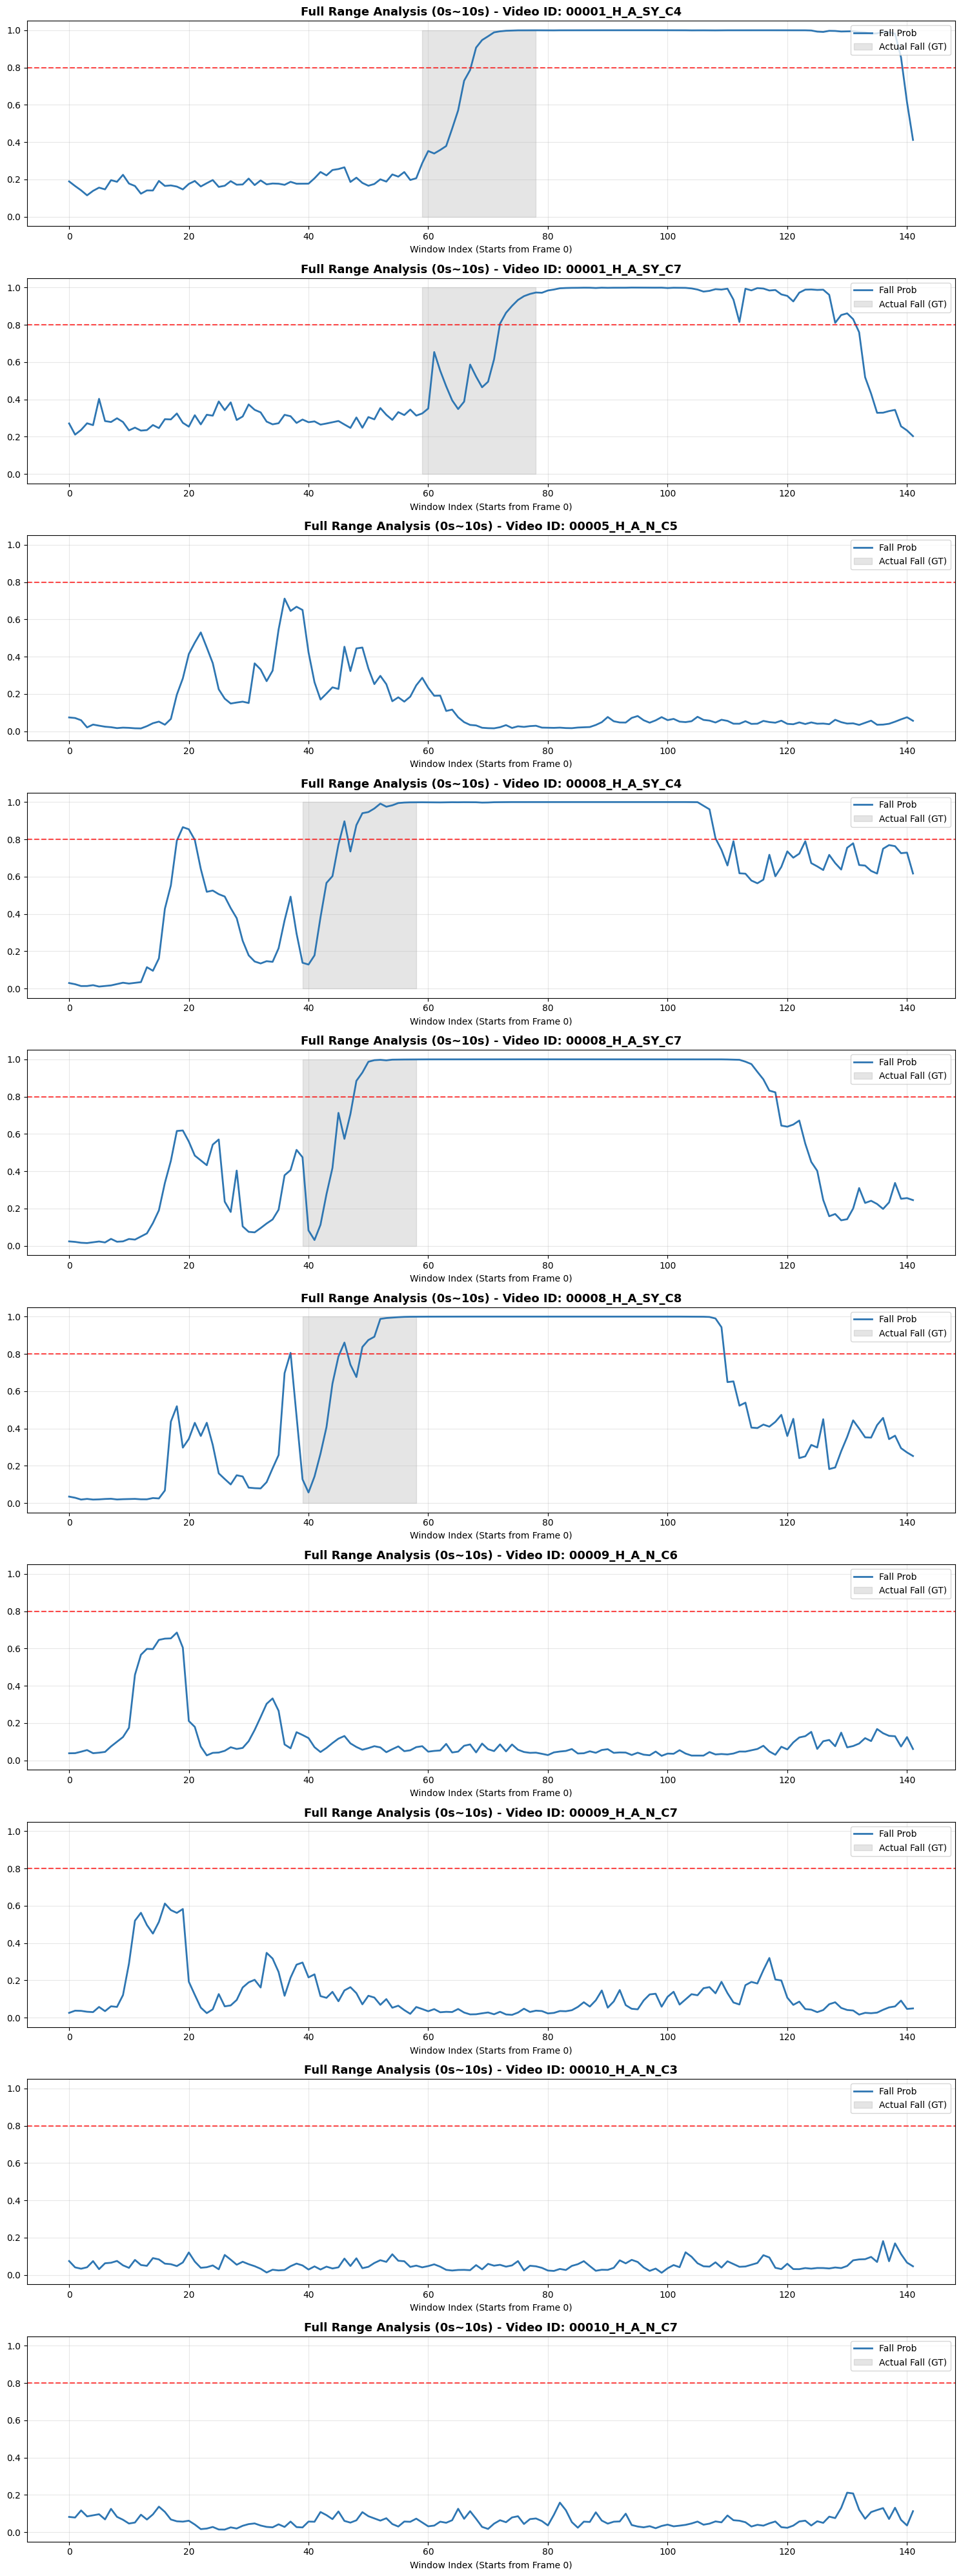

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_test_videos_full_range(df, model, group_test, feature_cols, mean, std, config, num_vids=10):
    test_video_ids = np.unique(group_test)

    selected_ids = test_video_ids[:num_vids]

    fig, axes = plt.subplots(num_vids, 1, figsize=(15, 4 * num_vids))
    if num_vids == 1: axes = [axes]

    for i, vid_id in enumerate(selected_ids):
        raw_video = df[df['video_id'] == vid_id].sort_values('frame').reset_index(drop=True)

        x_raw = raw_video[feature_cols].values
        x_norm = (x_raw - mean) / std

        full_windows = []
        for j in range(len(x_norm) - config.target_steps + 1):
            full_windows.append(x_norm[j : j + config.target_steps])

        full_windows = np.array(full_windows)

        preds = model.predict(full_windows, batch_size=256, verbose=0)
        probs = preds[:, 1]

        gt_labels = raw_video['label'].values[config.target_steps - 1:]

        ax = axes[i]
        ax.plot(probs, label='Fall Prob', color='#2E76B2', lw=2)
        ax.axhline(y=config.decision_threshold, color='red', linestyle='--', alpha=0.7)

        ax.fill_between(range(len(gt_labels)), 0, 1, where=(gt_labels == 1),
                        color='gray', alpha=0.2, label='Actual Fall (GT)')

        ax.set_title(f"Full Range Analysis (0s~10s) - Video ID: {vid_id}", fontsize=13, fontweight='bold')
        ax.set_ylim(-0.05, 1.05)
        ax.set_xlabel("Window Index (Starts from Frame 0)")
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_test_videos_full_range(df, model, group_test, feature_cols, mean, std, config, num_vids=10)

In [17]:
# 데이터 레이블 정리
if len(y_test.shape) > 1 and y_test.shape[1] > 1:
    y_test_labels = np.argmax(y_test, axis=1)
else:
    y_test_labels = y_test

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. 전체 테스트 데이터에 대한 추론 수행
print(f"🚀 테스트 데이터({len(x_test)} 샘플) 성능 분석 중...")
y_pred_probs = model.predict(x_test, batch_size=256, verbose=1)[:, 1]

# 2. 설정된 임계값(0.85) 적용하여 이진 분류
y_pred_binary = (y_pred_probs >= config.decision_threshold).astype(int)

# 3. 지표 계산
# y_test_labels는 아까 정의한 (N,) 형태의 실제 정답 레이블입니다.
accuracy = accuracy_score(y_test_labels, y_pred_binary)
precision = precision_score(y_test_labels, y_pred_binary)
recall = recall_score(y_test_labels, y_pred_binary)
f1 = f1_score(y_test_labels, y_pred_binary, average='macro')
pos_rate = np.mean(y_pred_binary) # Predicted Positive Rate

# 4. 결과 출력
print("\n" + "="*30)
print(f"테스트 성능 결과 (Threshold: {config.decision_threshold})")
print("-" * 30)
print(f"Accuracy:           {accuracy:.4f}")
print(f"Precision:          {precision:.4f}")
print(f"Recall:             {recall:.4f}")
print(f"Macro F1-score:     {f1:.4f}")
print(f"Pred Positive Rate: {pos_rate:.4f}")
print("="*30)

# 상세 리포트 출력
print("\n[Classification Report]")
print(classification_report(y_test_labels, y_pred_binary, target_names=['Normal', 'Fall']))

🚀 테스트 데이터(433006 샘플) 성능 분석 중...
1692/1692 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step

테스트 성능 결과 (Threshold: 0.8)
------------------------------
Accuracy:           0.8808
Precision:          0.8714
Recall:             0.8334
Macro F1-score:     0.8761
Pred Positive Rate: 0.3937

[Classification Report]
              precision    recall  f1-score   support

      Normal       0.89      0.91      0.90    254736
        Fall       0.87      0.83      0.85    178270

    accuracy                           0.88    433006
   macro avg       0.88      0.87      0.88    433006
weighted avg       0.88      0.88      0.88    433006



In [ ]:
# 세션 종료
#from google.colab import runtime
#runtime.unassign()